In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


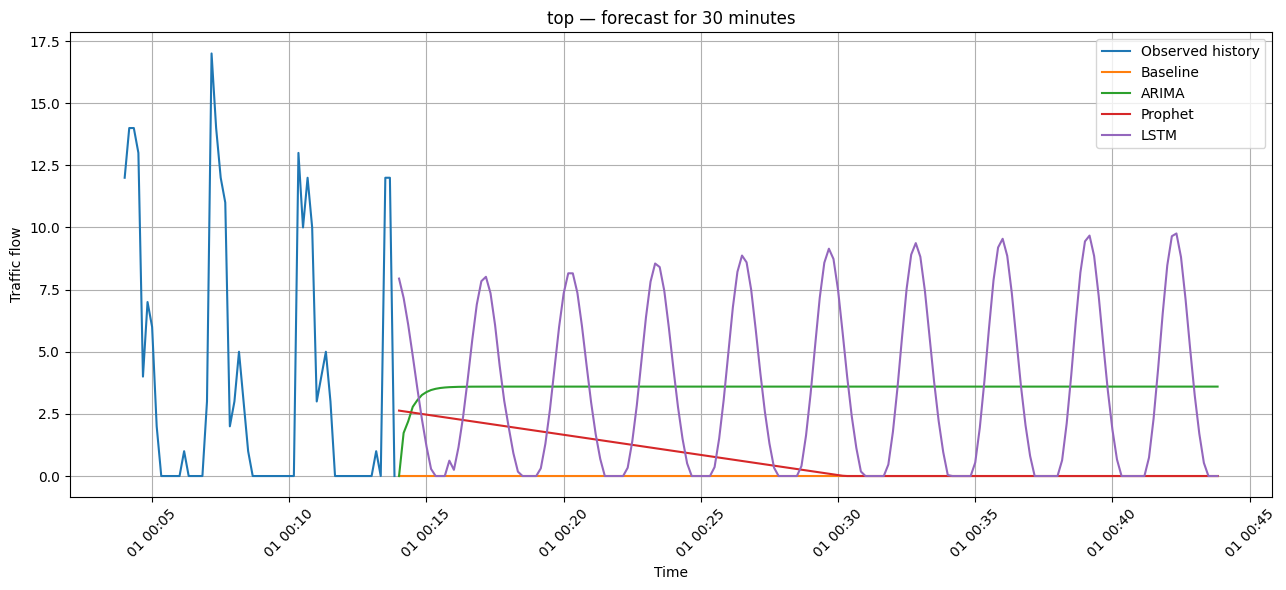

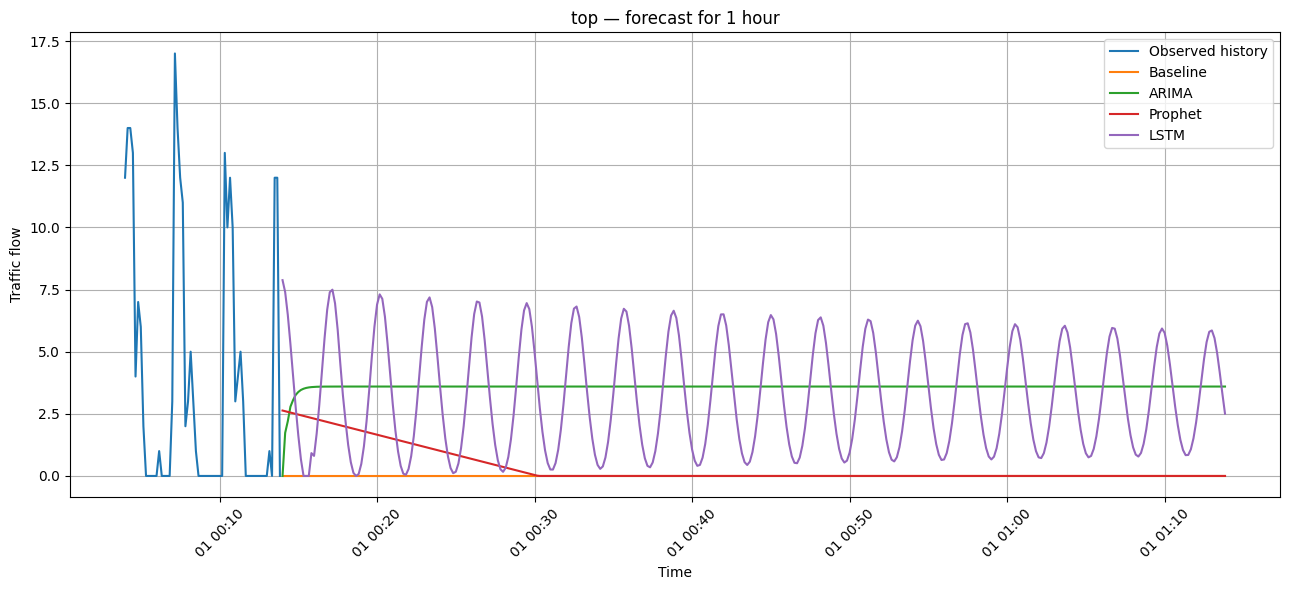

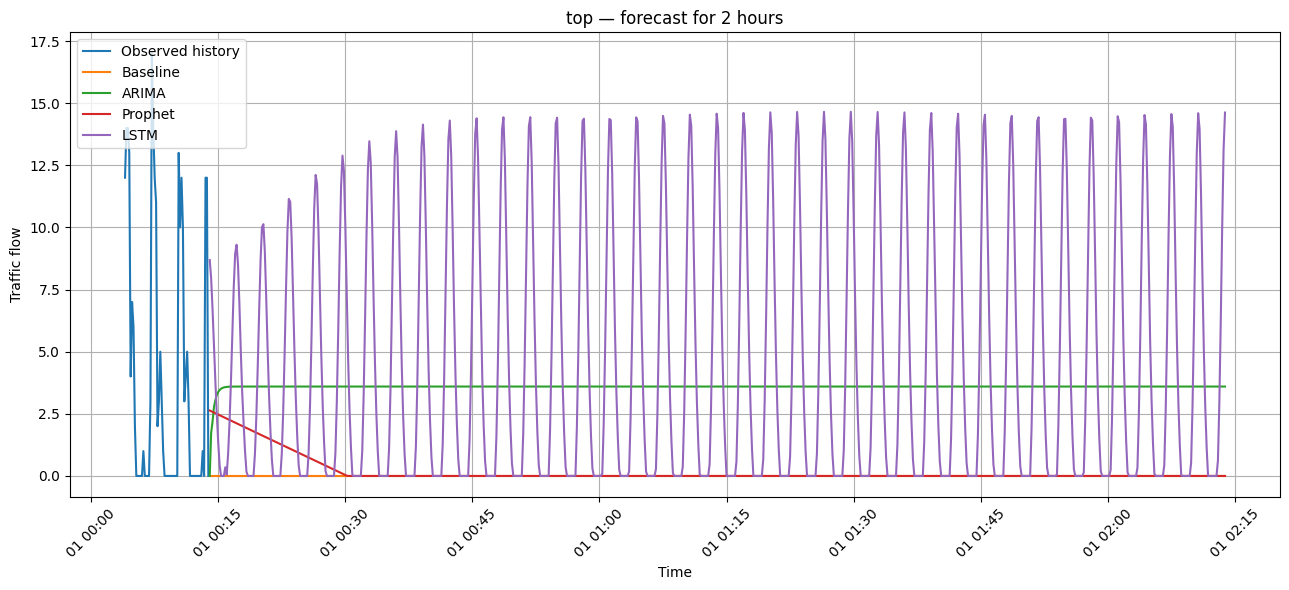

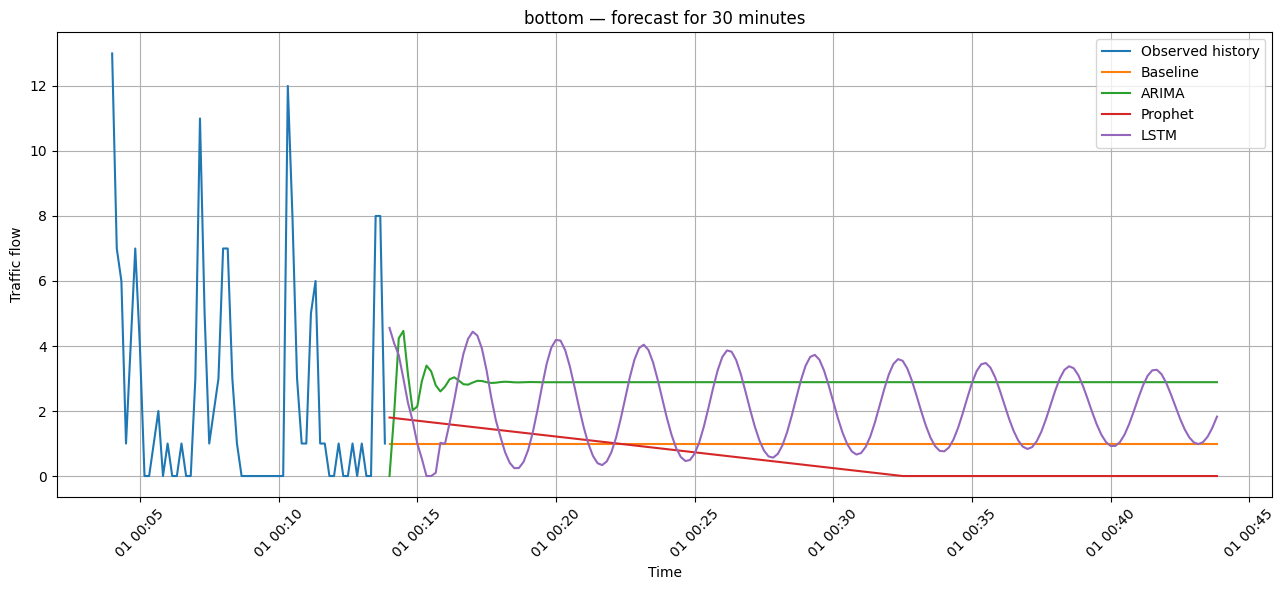

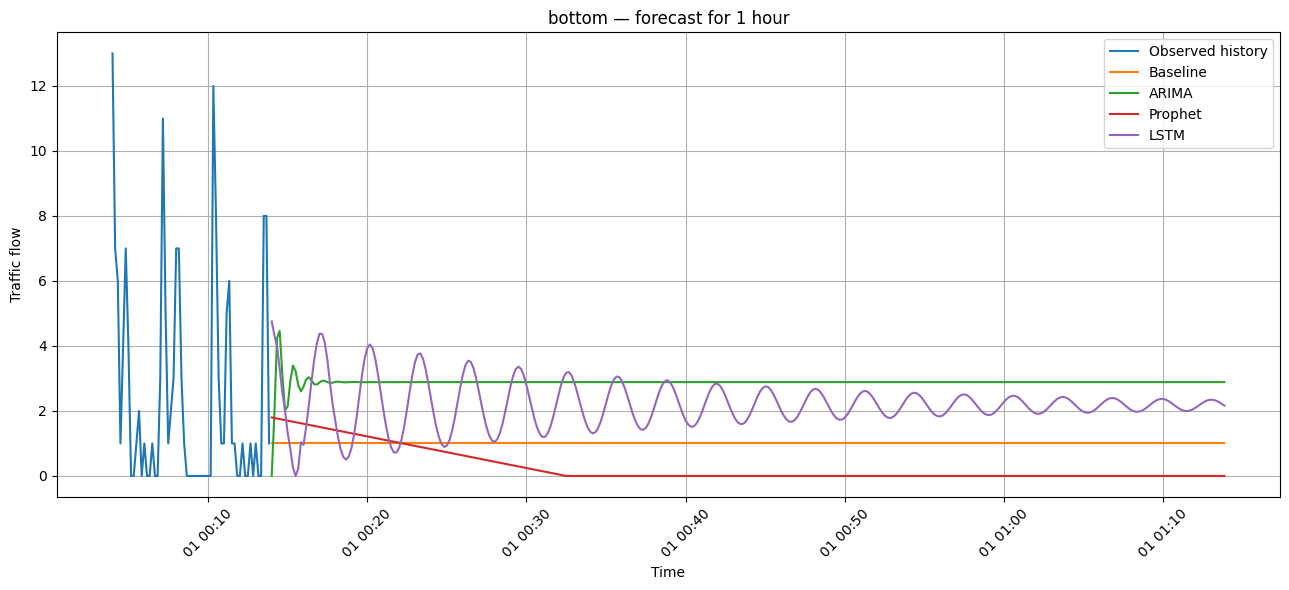

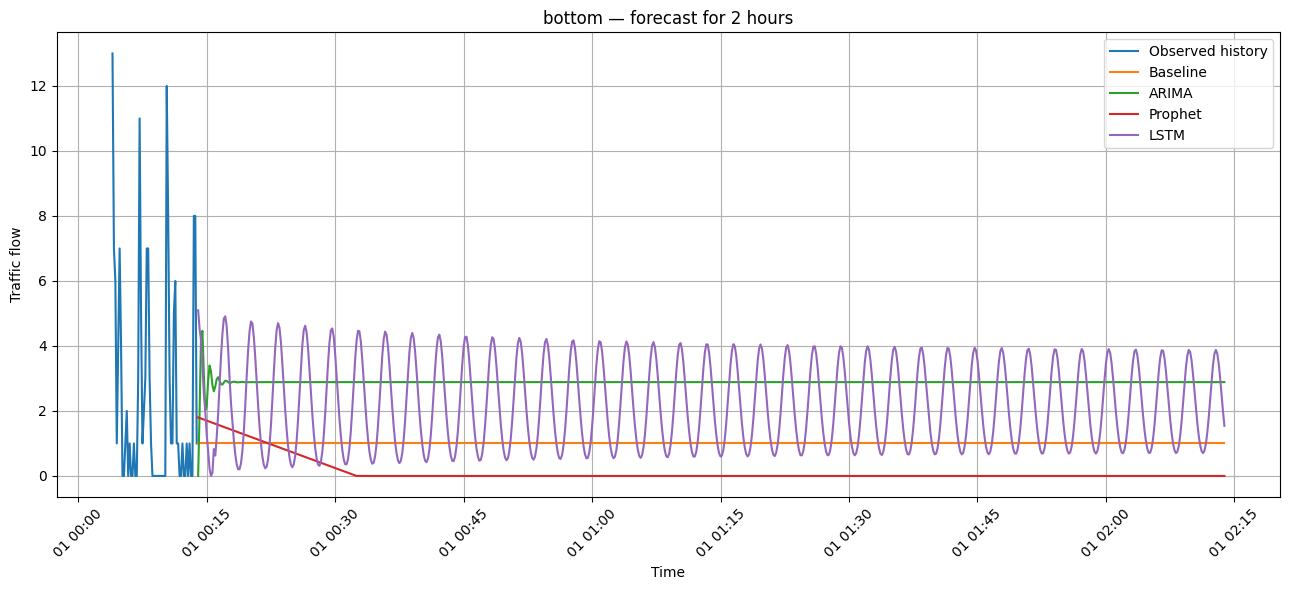

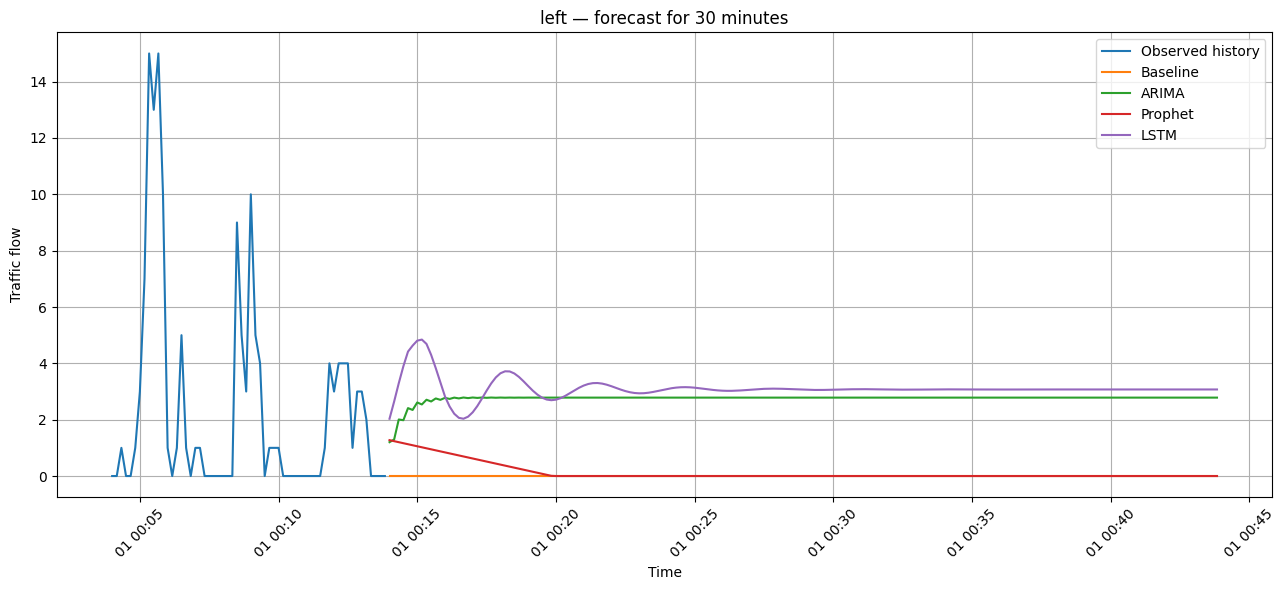

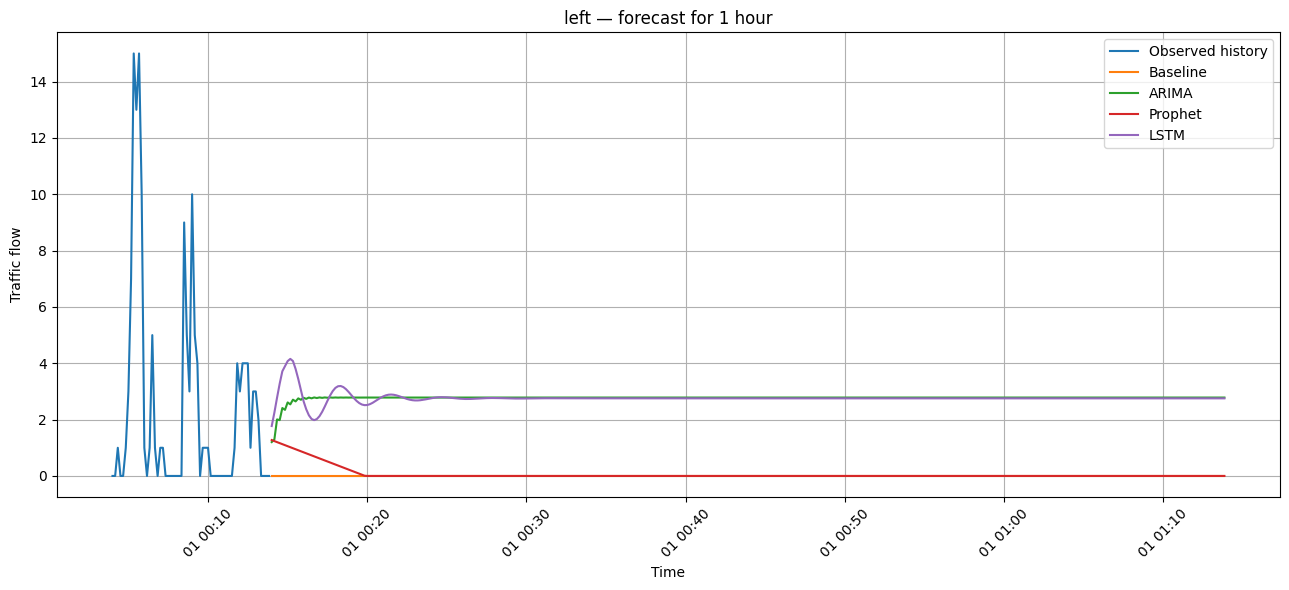

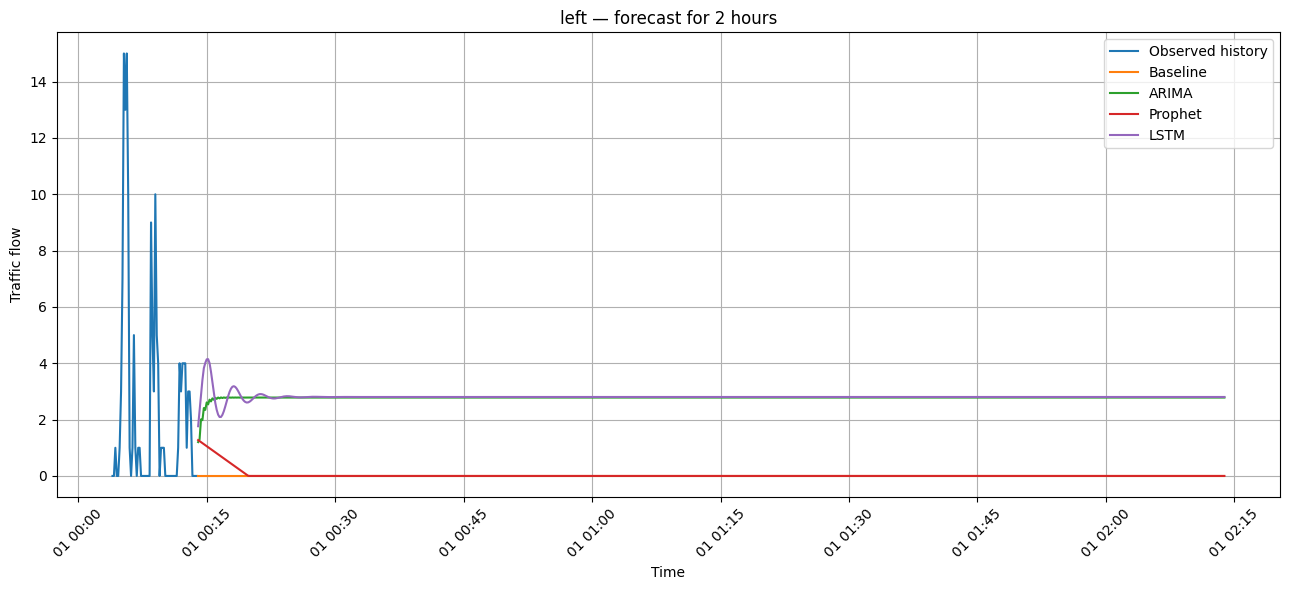

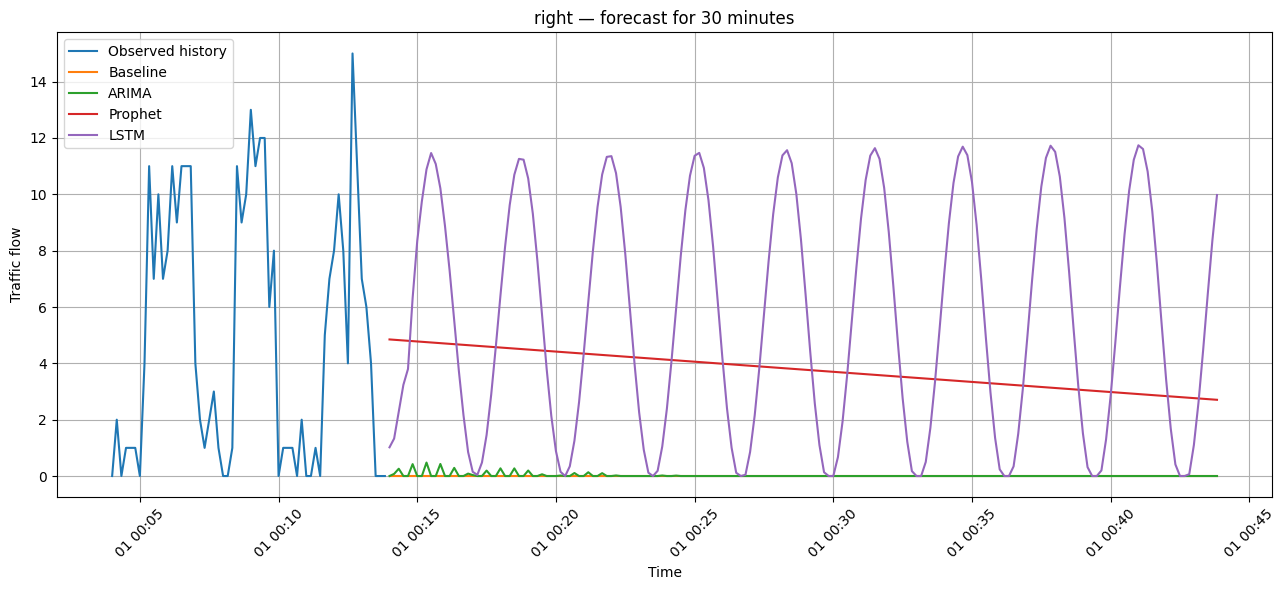

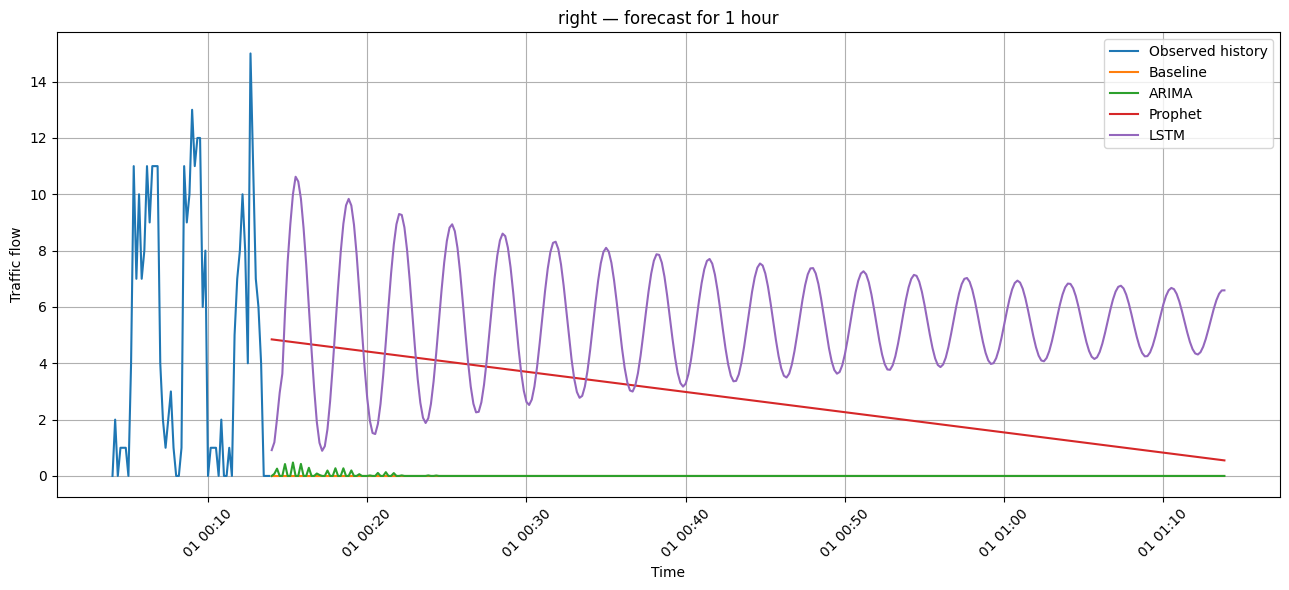

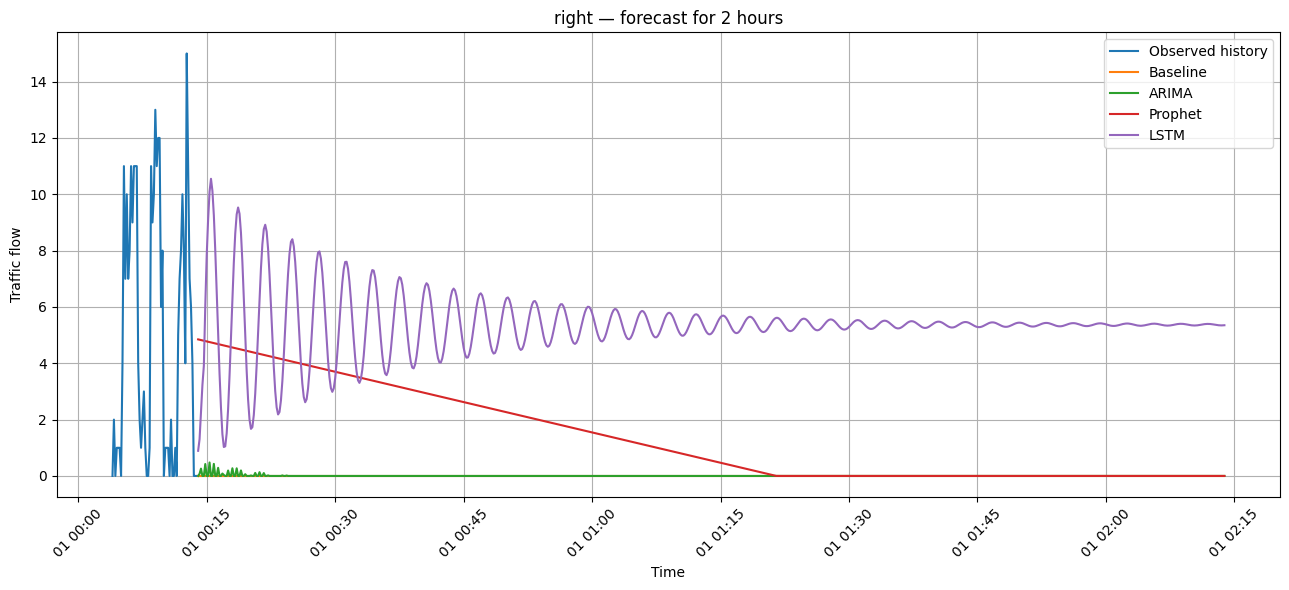

,direction,horizon,model,mean_forecast,max_forecast,min_forecast
0,top,30_minutes,Baseline,0.000,0.000,0.000
1,top,30_minutes,ARIMA,3.547,3.598,0.000
2,top,30_minutes,Prophet,0.720,2.632,0.000
3,top,30_minutes,LSTM,3.425,9.758,0.000
4,top,1_hour,Baseline,0.000,0.000,0.000
5,top,1_hour,ARIMA,3.572,3.598,0.000
6,top,1_hour,Prophet,0.360,2.632,0.000
7,top,1_hour,LSTM,3.268,7.879,0.000
8,top,2_hours,Baseline,0.000,0.000,0.000
9,top,2_hours,ARIMA,3.585,3.598,0.000


,horizon,model,mean_forecast,max_forecast,min_forecast
0,1_hour,ARIMA,2.308,2.832,0.300
1,1_hour,Baseline,0.250,0.250,0.250
2,1_hour,LSTM,3.427,6.853,0.666
3,1_hour,Prophet,0.851,2.638,0.138
4,2_hours,ARIMA,2.312,2.832,0.300
5,2_hours,Baseline,0.250,0.250,0.250
6,2_hours,LSTM,3.742,8.612,0.664
7,2_hours,Prophet,0.430,2.638,0.000
8,30_minutes,ARIMA,2.298,2.832,0.300
9,30_minutes,Baseline,0.250,0.250,0.250


Saved:
Q3_Forecasting/extended_forecasts.csv
Q3_Forecasting/extended_forecast_summary.csv


In [11]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


CSV_PATH = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_10_seconds.csv"
OUTPUT_DIR = Path("Q3_Forecasting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTION_COLS = ["top", "bottom", "left", "right"]
STEP_SECONDS = 10
FREQ_STR = "10s"

LSTM_LOOKBACK = 12
LSTM_EPOCHS = 30
LSTM_BATCH_SIZE = 16


def baseline_forecast(train_series, horizon):
    last_value = train_series.iloc[-1]
    return np.repeat(last_value, horizon)


def arima_forecast(train_series, horizon):
    order = (2, 1, 2) if len(train_series) >= 20 else (1, 1, 1)
    model = ARIMA(train_series, order=order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=horizon)
    forecast = np.maximum(np.array(forecast), 0)
    return forecast


def prophet_forecast(train_series, horizon, freq):
    prophet_df = pd.DataFrame({
        "ds": train_series.index,
        "y": train_series.values
    })

    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False
    )
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=horizon, freq=freq)
    forecast = model.predict(future)["yhat"].iloc[-horizon:].values
    forecast = np.maximum(forecast, 0)
    return forecast


def make_lstm_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])
    return np.array(X), np.array(y)


def lstm_forecast(train_series, horizon, lookback=12, epochs=30, batch_size=16):
    values = train_series.values.reshape(-1, 1)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values)

    if len(scaled) <= lookback + 5:
        return baseline_forecast(train_series, horizon)

    X, y = make_lstm_sequences(scaled, lookback)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(monitor="loss", patience=4, restore_best_weights=True)

    model.fit(
        X,
        y,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[es]
    )

    history_seq = scaled[-lookback:].reshape(1, lookback, 1)
    preds = []

    for _ in range(horizon):
        next_pred = model.predict(history_seq, verbose=0)[0, 0]
        preds.append(next_pred)
        next_pred_reshaped = np.array(next_pred).reshape(1, 1, 1)
        history_seq = np.concatenate([history_seq[:, 1:, :], next_pred_reshaped], axis=1)

    preds = np.array(preds).reshape(-1, 1)
    preds = scaler.inverse_transform(preds).flatten()
    preds = np.maximum(preds, 0)
    return preds


df = pd.read_csv(CSV_PATH)

flow_df = df[["time_seconds"] + DIRECTION_COLS].copy()
flow_df["timestamp"] = pd.to_datetime(flow_df["time_seconds"], unit="s")
flow_df = flow_df.set_index("timestamp")
flow_df = flow_df[DIRECTION_COLS].dropna()

history_steps = len(flow_df)

horizons = {
    "30_minutes": int((30 * 60) / STEP_SECONDS),
    "1_hour": int((60 * 60) / STEP_SECONDS),
    "2_hours": int((120 * 60) / STEP_SECONDS),
}

all_forecasts = []
summary_rows = []

for direction in DIRECTION_COLS:
    series = flow_df[direction].copy()

    for horizon_name, horizon_steps in horizons.items():
        baseline_pred = baseline_forecast(series, horizon_steps)
        arima_pred = arima_forecast(series, horizon_steps)
        prophet_pred = prophet_forecast(series, horizon_steps, FREQ_STR)
        lstm_pred = lstm_forecast(
            series,
            horizon_steps,
            lookback=LSTM_LOOKBACK,
            epochs=LSTM_EPOCHS,
            batch_size=LSTM_BATCH_SIZE
        )

        future_index = pd.date_range(
            start=series.index[-1] + pd.Timedelta(seconds=STEP_SECONDS),
            periods=horizon_steps,
            freq=FREQ_STR
        )

        forecast_df = pd.DataFrame({
            "timestamp": future_index,
            "direction": direction,
            "horizon": horizon_name,
            "Baseline": baseline_pred,
            "ARIMA": arima_pred,
            "Prophet": prophet_pred,
            "LSTM": lstm_pred
        })

        all_forecasts.append(forecast_df)

        summary_rows.extend([
            {"direction": direction, "horizon": horizon_name, "model": "Baseline", "mean_forecast": float(np.mean(baseline_pred)), "max_forecast": float(np.max(baseline_pred)), "min_forecast": float(np.min(baseline_pred))},
            {"direction": direction, "horizon": horizon_name, "model": "ARIMA", "mean_forecast": float(np.mean(arima_pred)), "max_forecast": float(np.max(arima_pred)), "min_forecast": float(np.min(arima_pred))},
            {"direction": direction, "horizon": horizon_name, "model": "Prophet", "mean_forecast": float(np.mean(prophet_pred)), "max_forecast": float(np.max(prophet_pred)), "min_forecast": float(np.min(prophet_pred))},
            {"direction": direction, "horizon": horizon_name, "model": "LSTM", "mean_forecast": float(np.mean(lstm_pred)), "max_forecast": float(np.max(lstm_pred)), "min_forecast": float(np.min(lstm_pred))}
        ])

        history_to_plot = min(60, len(series))
        hist_series = series.iloc[-history_to_plot:]

        plt.figure(figsize=(13, 6))
        plt.plot(hist_series.index, hist_series.values, label="Observed history")
        plt.plot(future_index, baseline_pred, label="Baseline")
        plt.plot(future_index, arima_pred, label="ARIMA")
        plt.plot(future_index, prophet_pred, label="Prophet")
        plt.plot(future_index, lstm_pred, label="LSTM")
        plt.title(f"{direction} — forecast for {horizon_name.replace('_', ' ')}")
        plt.xlabel("Time")
        plt.ylabel("Traffic flow")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

forecasts_df = pd.concat(all_forecasts, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)

summary_display = summary_df.copy()
summary_display["mean_forecast"] = summary_display["mean_forecast"].round(3)
summary_display["max_forecast"] = summary_display["max_forecast"].round(3)
summary_display["min_forecast"] = summary_display["min_forecast"].round(3)

display(summary_display)

summary_by_horizon = (
    summary_df.groupby(["horizon", "model"])[["mean_forecast", "max_forecast", "min_forecast"]]
    .mean()
    .reset_index()
)

summary_by_horizon[["mean_forecast", "max_forecast", "min_forecast"]] = summary_by_horizon[["mean_forecast", "max_forecast", "min_forecast"]].round(3)

display(summary_by_horizon)

forecasts_df.to_csv(OUTPUT_DIR / "extended_forecasts.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "extended_forecast_summary.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "extended_forecasts.csv")
print(OUTPUT_DIR / "extended_forecast_summary.csv")